# STEP1:IMPORT NECCESSARY LIBRARIES

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# STEP 2:LOAD THE DATASET

In [4]:
# Load the dataset
df = pd.read_csv("loan_approval_dataset.csv")

In [5]:
# Print the first few rows to understand the structure
print(df.head())

   CreditScore  Income  LoanHistory  LoanApproval
0          402  126296            9             0
1          735  101182            1             1
2          570  102565            1             0
3          406   49402            0             0
4          371   24263            9             0


# STEP 3:CHECKING FOR MISSING VALUES

In [6]:
# Check for missing values and handle them (if any)
print(df.isnull().sum())


CreditScore     0
Income          0
LoanHistory     0
LoanApproval    0
dtype: int64


# STEP 4:FEATURE SELECTION AND TARGET VARIABLE

In [7]:
# Feature selection and target variable
X = df[['CreditScore', 'Income', 'LoanHistory']]
y = df['LoanApproval']


# STEP 5:SPLIT THE DATA

In [8]:
# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# STEP 6:INITIALIZE RANDOM FOREST CLASSIFIER

In [9]:
# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


# STEP 7:TRAIN THE MODEL

In [10]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# STEP 8:TRAIN THE MODEL

In [11]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# STEP9:MAKE PREDICTIONS

In [12]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)


# STEP 10:EVALUATE THE MODEL

In [13]:
# Evaluate the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.98
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       180
           1       1.00      0.85      0.92        20

    accuracy                           0.98       200
   macro avg       0.99      0.93      0.96       200
weighted avg       0.99      0.98      0.98       200



# STEP 11:CONFUSION MATRIX

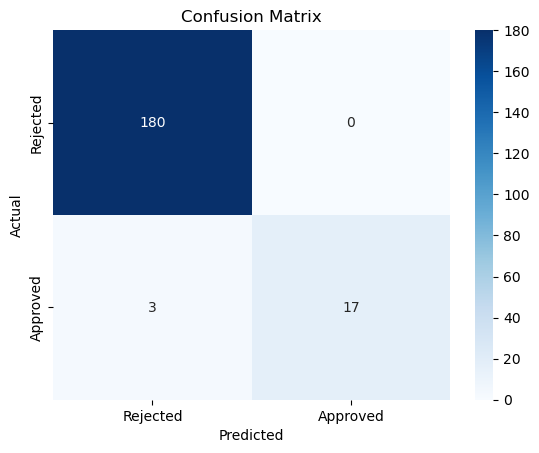

In [14]:
# Confusion matrix for better understanding of the results
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# STEP 12:FEATURE IMPORTANT VISUALIZATION

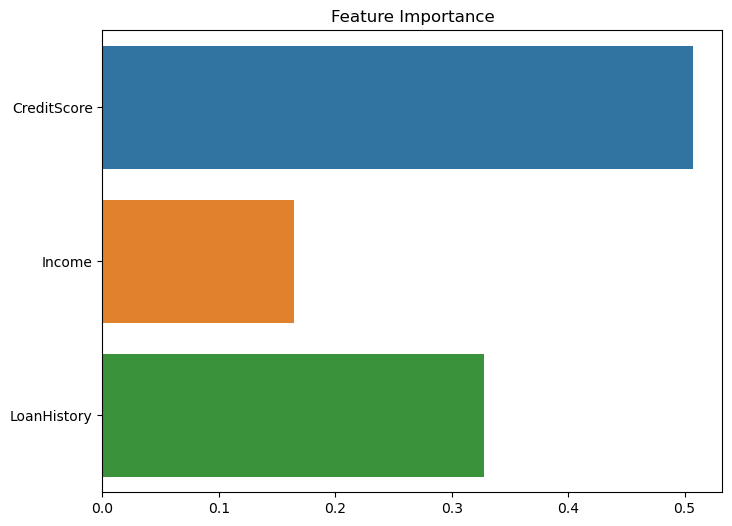

In [15]:
# Feature importance visualization
feature_importances = rf_model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importances, y=features)
plt.title('Feature Importance')
plt.show()
